## 2D spectrum

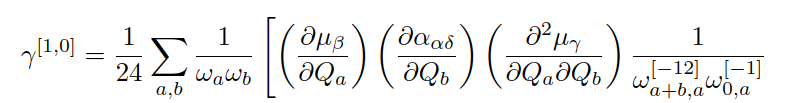

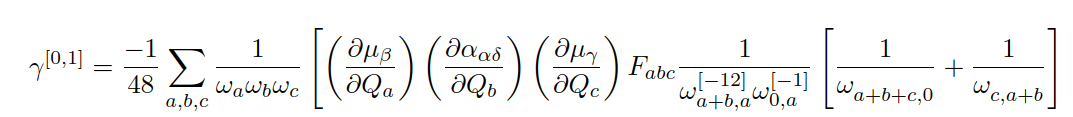

In [31]:
# w1, w1-w2
import math
import numpy as np
import matplotlib.pyplot as plt

deriv_mu = np.array([
    np.array([0.3, 0.1, 0.1]), 
    np.array([0.1, 0.3, 0.1]), 
    np.array([0.1, 0.1, 0.3])
])

deriv_alpha = np.array([
    np.array([0.3, 0.1, 0.1]), 
    np.array([0.1, 0.3, 0.1]), 
    np.array([0.1, 0.1, 0.3])
])

w = {0: 4, 1: 6, 2: 11}
combs = {}

a, b, c = 0, 1, 2

# Gamma = np.array([
#     np.array([0.001, 0.001, 0.001]),
#     np.array([0.001, 0.001, 0.001]),
#     np.array([0.001, 0.001, 0.001])
# ])

Gamma = 0.001


# electrical anharmonicity
# @np.vectorize
def el_anh(w1, w2, deriv_mu, deriv_alpha, Gamma, w):
    """
    a, b, c - normal modes indices as strings
    w - dictionary of normal modes freqs, including some combination bands and overtones
        k:v '(str index or str combination)': freq
    w1 - range of w1 axis values
    w2 - range of w2 axis values
    w1mw2 = w1-w2
    deriv_mu, deriv_alpha - 2D arrays
    """
    # -----------------------------------------------------------------------
    
    # -----------------------------------------------------------------------
    
    w1mw2 = w1-w2
    w_0 = 0

    totalres = np.zeros((len(w1), len(w2)))
    
    for a in range(3):
        for b in range(3):
            # print(a, b)
            firstfrac = 1/ w[a] / w[b]
            derivs1 = deriv_mu[a, a] * deriv_alpha[b, b] * deriv_mu[a, b]
            
            resonance1_1 = (w[a] + w[b] - 5) - w[a] - w1mw2 - Gamma
            resonance2_1 = w_0 - w[a] + w1 - Gamma
            term1 = derivs1 / resonance1_1 / resonance2_1
            
            totalres += firstfrac * (term1)
    # print(totalres)
    return totalres/24


def mech_anh(w1, w2, deriv_mu, deriv_alpha, Gamma, w):
    w1mw2 = w1-w2
    w_0 = 0

    totalres = np.zeros((len(w1), len(w2)))
    
    for a in range(3):
        for b in range(3):
            firstfrac = 1 / w[a] / w[b] / w[c]
            fracs = 1 / ((w[a] + w[b] + w[c] - 5) - w_0) + 1 / (w[c] - (w[a] + w[b] - 5))
            Fabc = 0.5
            derivs1 = deriv_mu[a, a] * deriv_alpha[b, b] * deriv_mu[c, c] 
            
            resonance1_1 = (w[a] + w[b] - 1) - w[a] - w1mw2 - Gamma 
            resonance2_1 = w_0 - w[a] - Gamma
            
            term1 = derivs1 * fracs / resonance1_1 / resonance2_1
            
            totalres += firstfrac * (term1)
    
    return -totalres/48

# w1 = np.array([4, 8, 9])
# w2 = np.array([2, 6, 11])
# xx, yy = np.meshgrid(w1, w1+w2)

# z = (el_anh(xx, yy, deriv_mu, deriv_alpha, Gamma, w) + mech_anh(xx, yy, deriv_mu, deriv_alpha, Gamma, w))**2
# np.set_printoptions(suppress=True)
# print(z)

import matplotlib.pyplot as plt
   
def spectrum(w1, w2, w, option1=False, prt=False):
    
    if option1:
        X, Y = np.meshgrid(w1, w1-w2)
    else:
        X, Y = np.meshgrid(w1, w2)


    # compute the third dimension at each point on the grid
    Z = (el_anh(X, Y, deriv_mu, deriv_alpha, Gamma, w) + mech_anh(X, Y, deriv_mu, deriv_alpha, Gamma, w))**2 * 10**8
    # Z = el_anh(X, Y)**2
    print(Z) if prt else None

    for k, v in w.items():
        print(k, v) if prt else None

    # plot the points with the third dimension as color
    fig, ax = plt.subplots()
    fig.set_size_inches(12, 10)
    
    print(len(X.flatten()), len(Y.flatten()), len(Z.flatten()))
    sc = ax.scatter(X.flatten(), Y.flatten(), c=Z.flatten(), cmap='viridis', s=200)

    ax.set_xlabel('w1', fontsize=18)

    if option1:
        ax.set_ylabel('w1-w2', fontsize=18)
    else:
        ax.set_ylabel('w2', fontsize=18)

    plt.colorbar(sc)
    plt.grid()

    # set the tick frequency on x and y axis
    ax.set_xticks(np.linspace(-2, 15, 18))
    ax.set_yticks(np.linspace(-2, 15, 18))
    ax.set_xlim(-1, 9)
    ax.set_ylim(-1, 9)
    for i in range(len(w1)):
        for j in range(len(w2)):
            ax.text(X[i, j]-0.3, Y[i, j]+0.3, 
                    f'{Z[i, j]:.5f}',
                    #f'({X[i, j]:.2f}, {Y[i, j]:.2f}, {Z[i, j]:.2f})',
                    ha='right', va='bottom')
    plt.show()

16 16 16


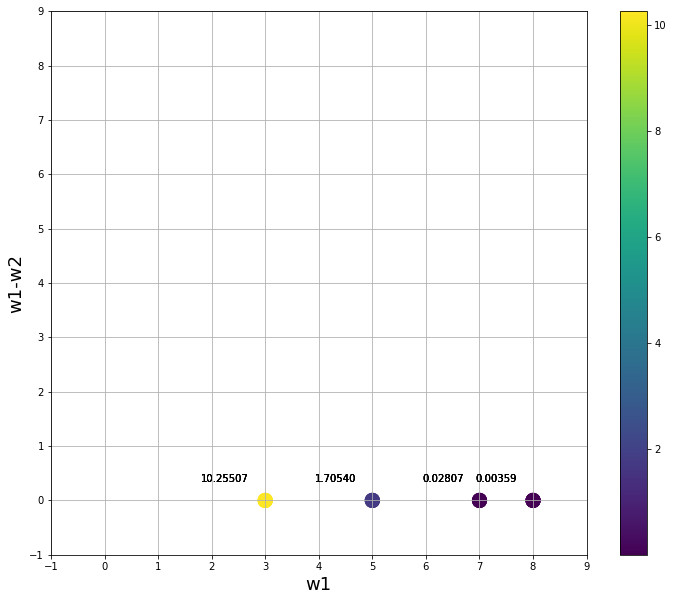

In [32]:
w2 = np.array([3, 5, 7, 8])
w1 = np.array([3, 5, 7, 8])

w = {0: 4, 1: 6, 2: 11}

# spectrum(w1, w2, w, option1=False, prt=True)
spectrum(w1, w2, w, option1=True)